<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/ProyectoFinalProgADAP_263150.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Proyecto final de Programación para Analítica Descriptiva y Predictiva**
## Nombre del Proyecto: Bank Marketing
## Autor: Álvaro Hernández Jarquín
## Matrícula: 263150
## Fecha: 20 de noviembre de 2025

# **1. Introducción**

## Descripción del problema
La base de datos seleccionada proviene del *Bank Marketing Data Set* (UCI Machine Learning Repository), una institución bancaria portuguesa y contiene información sobre campañas de marketing. Estas campañas se basaron principalmente en llamadas telefónicas realizadas entre mayo de 2008 y noviembre de 2010 para determinar si un cliente accedería a contratar un producto financiero específico. Regularmente se realizaban más de una llamada al mismo cliente. El objetivo principal es modelar la probabilidad de que un cliente contrate o no un depósito a plazo fijo, a partir de las variables recabadas, por ejemplo: características demográficas, historial financiero, duración de la llamada y resultado de campañas anteriores.


## Objetivo del análisis
Se pretende desarrollar modelos de clasificación que permitan identificar con alta precisión cuáles clientes tienen mayor probabilidad de contratar el depósito a plazo fijo, para lograr:
* Optimizar recursos. Dependiendo de las variables, el banco se puede centrar en los clientes que tienen más alta probabilidad de aceptar este producto, lo que puede reducir el número de llamadas y, por ende, el tiempo del personal.
* Mejorar la experiencia de los clientes. Los clientes que no tienen tanta probabilidad de adquirir el producto no serán expuestos a dicha propuesta.
* Aumentar ingresos. Ya que se realizarán más llamadas a clientes con mayor probabilidad de aceptar, aumentarán las ventas.

## Impacto esperado
Un modelo predictivo robusto permitirá reducir costos de operación y maximizar el retorno por campaña.

## Fuente de datos
Los datos provienen del *UCI Machine Learning Repository* (Universidad de California, Irvine), específicamente del conjunto de datos denominado *Bank Marketing Data Set*. Estos datos fueron recolectados y publicados originalmente por S. Moro, P. Rita y P. Cortez en 2014 y contienen información real sobre campañas de marketing telefónico de un banco portugués realizadas entre mayo de 2008 y noviembre de 2010.


# **2. Captura y carga de datos**

## Datos
* Fuente: Los datos se obtienen del archivo local `bank-additional-full.csv`, proveniente del repositorio UCI Machine Learning, carpeta "Bank Marketing".

* Formato: El archivo es un texto plano con formato CSV, con delimitador (;).

* Dimensiones: El dataset contiene 41,188 observaciones (filas) y 21 variables (columnas).

## Problemas en la carga de datos.
Uno de los problemas más comunes al cargar este dataset es que, a diferencia del estándar CSV convencional que usa comas (,), este archivo utiliza punto y coma (;) como separador de campos, es necesario especificar el parámetro sep=';'.


In [21]:
# Importamos las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Cargamos el dataset
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/bank-additional-full.csv', sep=';')

# Mostramos dimensiones del dataset
print("="*27)
print('Dimensiones del dataset')
print(df.shape)
print("="*27)

print()

# Mostramos primeras 5 filas
print("="*80)
print("Primeras 5 filas:")
print(df.head())
print("="*80)

Dimensiones del dataset
(41188, 21)

Primeras 5 filas:
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

 

#**3.Transformación y Preprocesamiento - Data Wrangling**


## Identificación de Tipos de Datos

## Cantidad de Valores nulos




In [5]:
# Mostramos el tipo de datos del dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## Identificación de tipos de datos
Con el resumen del dataset (`df.info()`), se observa que la base de datos contiene 21 variables:
* 11 columnas categóricas con tipo `object`.
* 10 variables numéricas, 5 tipo `int` y 5 tipo `float`.

Las variables categóricas requerirán técnicas de codificación (One-Hot Encoding) en la etapa de modelado. Las variables numéricas se encuentran en formato adecuado para ser exploradas mediante estadísticas descriptivas y visualizaciones.

In [6]:
# Hacemos una lista con las columnas de tipo 'object'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_summary = {}

# Obtenemos las categorías únicas
for col in categorical_cols:
    unique_values = df[col].unique().tolist()
    categorical_summary[col] = unique_values

print("Categorías únicas por Columna Categórica")
for col, values in categorical_summary.items():
    print(f"\n{col.upper()}({len(values)} categorías):")
    if len(values) > 15:
        print(values[:15] + ['...'])
    else:
        print(values)

Categorías únicas por Columna Categórica

JOB(12 categorías):
['housemaid', 'services', 'admin.', 'blue-collar', 'technician', 'retired', 'management', 'unemployed', 'self-employed', 'unknown', 'entrepreneur', 'student']

MARITAL(4 categorías):
['married', 'single', 'divorced', 'unknown']

EDUCATION(8 categorías):
['basic.4y', 'high.school', 'basic.6y', 'basic.9y', 'professional.course', 'unknown', 'university.degree', 'illiterate']

DEFAULT(3 categorías):
['no', 'unknown', 'yes']

HOUSING(3 categorías):
['no', 'yes', 'unknown']

LOAN(3 categorías):
['no', 'yes', 'unknown']

CONTACT(2 categorías):
['telephone', 'cellular']

MONTH(10 categorías):
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']

DAY_OF_WEEK(5 categorías):
['mon', 'tue', 'wed', 'thu', 'fri']

POUTCOME(3 categorías):
['nonexistent', 'failure', 'success']

Y(2 categorías):
['no', 'yes']


## Cantidad de valores nulos
El dataset no contiene valores nulos, todas las filas (41,188) tienen conteo completo (non-null) en cada columna. Sin embargo, en varias variables categóricas aparecen categorías como `unknown` o `nonexistent`, que indican que no se tiene información, aunque no son técnicamente valores nulos. Así que deberemos tratarlas en el preprocesamiento, dependiendo del modelo que se decida aplicar.

# **4. Análisis Descriptivo de Datos**

## Preguntas a responder con el análisis descriptivo (AD)
1. ¿Cuál es la efectividad de la venta del producto? yes = éxito, no = fracaso



In [7]:
# Conteo y porcentaje de la variable objetivo 'y'
target_counts = df['y'].value_counts()
target_percentage = df['y'].value_counts(normalize=True) * 100

print("Conteo absoluto de suscripciones (y):")
print(target_counts)
print("\nPorcentaje de suscripciones (%):")
print(target_percentage)

Conteo absoluto de suscripciones (y):
y
no     36548
yes     4640
Name: count, dtype: int64

Porcentaje de suscripciones (%):
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


* El análisis revela un alto desbalance de clases: aproximadamente el 88.73% de los clientes no suscribieron el depósito
* Este desequilibrio debe ser considerado al evaluar modelos predictivos, ya que la Accuracy puede ser engañosa.

2. ¿Cómo se distribuyen las medidas numéricas como edad, duración, campaña?


In [8]:
# Resumen estadístico para variables numéricas clave
numeric_vars = ['age', 'duration', 'campaign', 'pdays']
print(df[numeric_vars].describe())

               age      duration      campaign         pdays
count  41188.00000  41188.000000  41188.000000  41188.000000
mean      40.02406    258.285010      2.567593    962.475454
std       10.42125    259.279249      2.770014    186.910907
min       17.00000      0.000000      1.000000      0.000000
25%       32.00000    102.000000      1.000000    999.000000
50%       38.00000    180.000000      2.000000    999.000000
75%       47.00000    319.000000      3.000000    999.000000
max       98.00000   4918.000000     56.000000    999.000000


* La edad media es 40 años; el rango de edad es entre 17 a 98 años (es un rango muy grande). La mayor parte de los clientes se encuentran entre 32 y 47 años.
* La duración media es de 258 s. Los valores de duración se concentran en los más altos, hay más llamadas largas.
* Se tienen 2.56 contactos en promedio y el rango está entre 1 y 56. El 75% de los clientes tuvieron 3 contactos o menos.
* El día de último contacto dominante es 999, así que se infiere que significa que no ha habido contacto previo.

3. ¿Cómo se relacionan las categorías como trabajo, estado civil, educación y préstamos?


In [9]:
# Lista de variables categóricas a analizar
categorical_vars = ['job', 'marital', 'education', 'housing', 'loan']

# Calculamos tablas cruzadas con la variable objetivo 'y'
for col in categorical_vars:
    print("="*80)
    print(f"Relación entre {col.upper()} y la suscripción (y):")
    print(pd.crosstab(df[col], df['y'], normalize='index') * 100)


Relación entre JOB y la suscripción (y):
y                     no        yes
job                                
admin.         87.027442  12.972558
blue-collar    93.105684   6.894316
entrepreneur   91.483516   8.516484
housemaid      90.000000  10.000000
management     88.782490  11.217510
retired        74.767442  25.232558
self-employed  89.514426  10.485574
services       91.861930   8.138070
student        68.571429  31.428571
technician     89.173958  10.826042
unemployed     85.798817  14.201183
unknown        88.787879  11.212121
Relación entre MARITAL y la suscripción (y):
y                no        yes
marital                       
divorced  89.679098  10.320902
married   89.842747  10.157253
single    85.995851  14.004149
unknown   85.000000  15.000000
Relación entre EDUCATION y la suscripción (y):
y                           no        yes
education                                
basic.4y             89.750958  10.249042
basic.6y             91.797557   8.202443
basic.9y 

* En la variable `job`, `student` es el más alto de todos, con 31.4% y en segundo lugar está `retired` con 25.2%.
* En `marital`, los solteros tienen la aceptación más alta con 14%.
* La gente que más contrata el producto según su educación es la que no tiene estudios con 22%. En porcentaje alto se encuentran `university.degree` y `profesional.course` con 13% y 11%
* Los dos valores de `housing` son muy similares.
* La relación entre `loan` y suscripción es también muy similar.

Debido a que estos valores son absolutos, se realizará un análisis del porcentaje de impacto de cada categoría

In [14]:
# Identificamos las variables categóricas
cat_vars = df.select_dtypes(include=['object']).columns.tolist()

resultados = {}

for var in cat_vars:
    tabla = pd.crosstab(df[var], df['y'], normalize='index') * 100  # % yes/no dentro de cada categoría
    tabla.columns = [col + "_pct" for col in tabla.columns]

    # Frecuencia absoluta
    freq_abs = df[var].value_counts()

    # Frecuencia relativa (densidad)
    freq_rel = df[var].value_counts(normalize=True) * 100

    # Unimos todo en una sola tabla
    resumen = pd.concat([freq_abs, freq_rel, tabla], axis=1)
    resumen.columns = ['frecuencia_abs', 'frecuencia_pct', 'no_pct', 'yes_pct']

    resultados[var] = resumen.sort_values('frecuencia_abs', ascending=False)

# Mostramos los resultados
for var, tabla in resultados.items():
    print("="*80)
    print(f" VARIABLE: {var.upper()}")
    print("="*80)
    display(tabla)


 VARIABLE: JOB


,frecuencia_abs,frecuencia_pct,no_pct,yes_pct
job,,,,
admin.,10422,25.303486,87.027442,12.972558
blue-collar,9254,22.467709,93.105684,6.894316
technician,6743,16.371273,89.173958,10.826042
services,3969,9.636302,91.861930,8.138070
management,2924,7.099155,88.782490,11.217510
retired,1720,4.175974,74.767442,25.232558
entrepreneur,1456,3.535010,91.483516,8.516484
self-employed,1421,3.450034,89.514426,10.485574
housemaid,1060,2.573565,90.000000,10.000000


 VARIABLE: MARITAL


,frecuencia_abs,frecuencia_pct,no_pct,yes_pct
marital,,,,
married,24928,60.522482,89.842747,10.157253
single,11568,28.085850,85.995851,14.004149
divorced,4612,11.197436,89.679098,10.320902
unknown,80,0.194231,85.000000,15.000000


 VARIABLE: EDUCATION


...

,frecuencia_abs,frecuencia_pct,no_pct,yes_pct
day_of_week,,,,
thu,8623,20.935709,87.881248,12.118752
mon,8514,20.671069,90.051680,9.948320
wed,8134,19.748470,88.332924,11.667076
tue,8090,19.641643,88.220025,11.779975
fri,7827,19.003108,89.191261,10.808739


 VARIABLE: POUTCOME


,frecuencia_abs,frecuencia_pct,no_pct,yes_pct
poutcome,,,,
nonexistent,35563,86.343110,91.167787,8.832213
failure,4252,10.323395,85.771402,14.228598
success,1373,3.333495,34.887109,65.112891


 VARIABLE: Y


,frecuencia_abs,frecuencia_pct,no_pct,yes_pct
y,,,,
no,36548,88.734583,100.0,0.0
yes,4640,11.265417,0.0,100.0


* A pesar de que `student` representa la tasa de suscripción más alta, 31.4% como vimos en el cuadro anterior, su población significa un 2.1% del total, por lo que iniciativas que intenten aumentar su nivel de suscripción no serían tan relevantes. Una estrategia más efectiva, sería mejorar la tasa de conversión de admin o blue-collar que representa el 25.3% del total. Este análisis puede ser usado para cada variable.


## Explicación de estadísticas básicas aplicadas, visualización de datos con gráficos y resumen de las respuestas

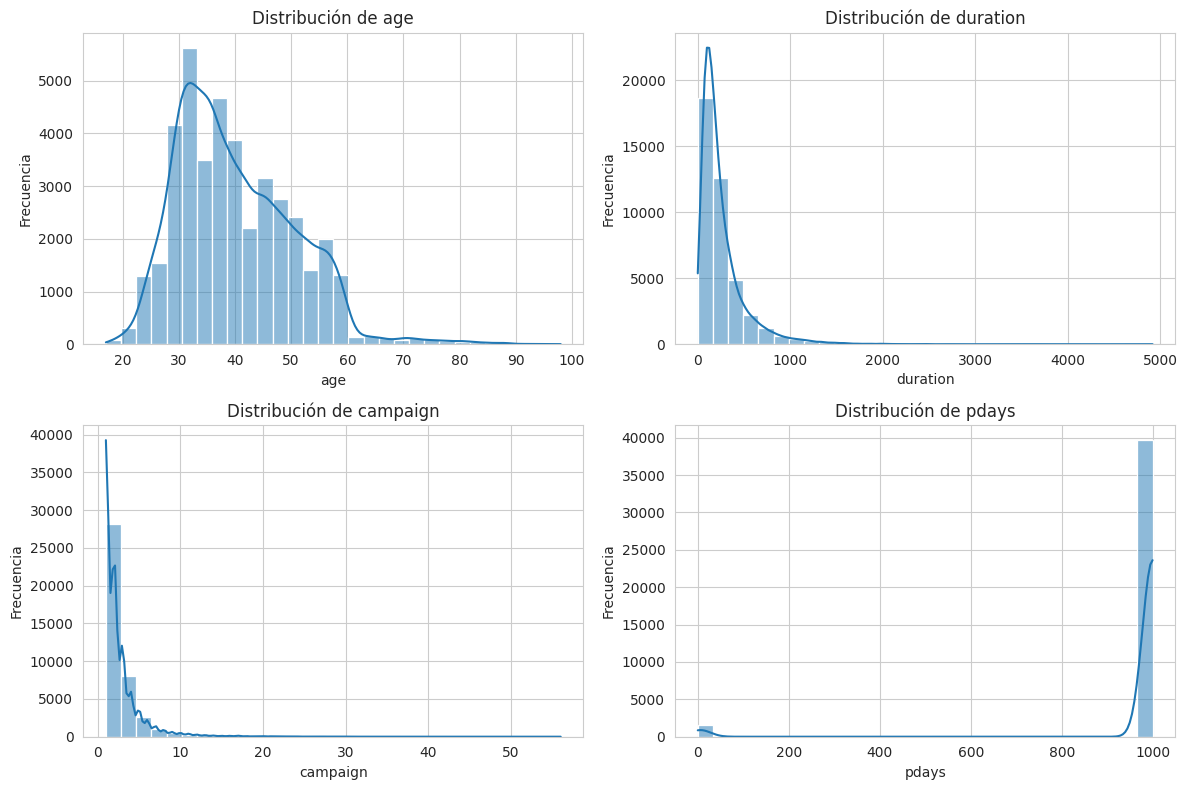

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Realizamos histograma de variables numéricas
numericas = ["age", "duration", "campaign", "pdays"]

plt.figure(figsize=(12, 8))

for i, col in enumerate(numericas, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

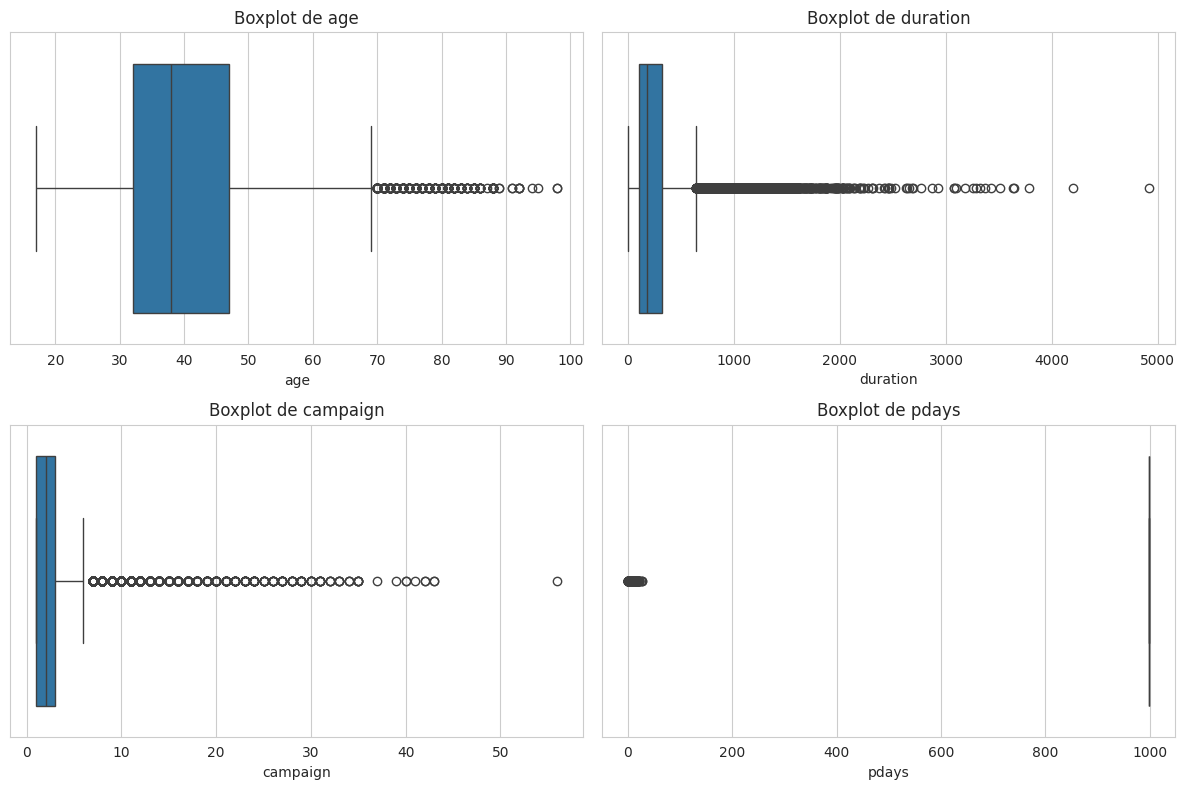

In [17]:
# Realizamos boxplots de variables numéricas
plt.figure(figsize=(12, 8))

for i, col in enumerate(numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()


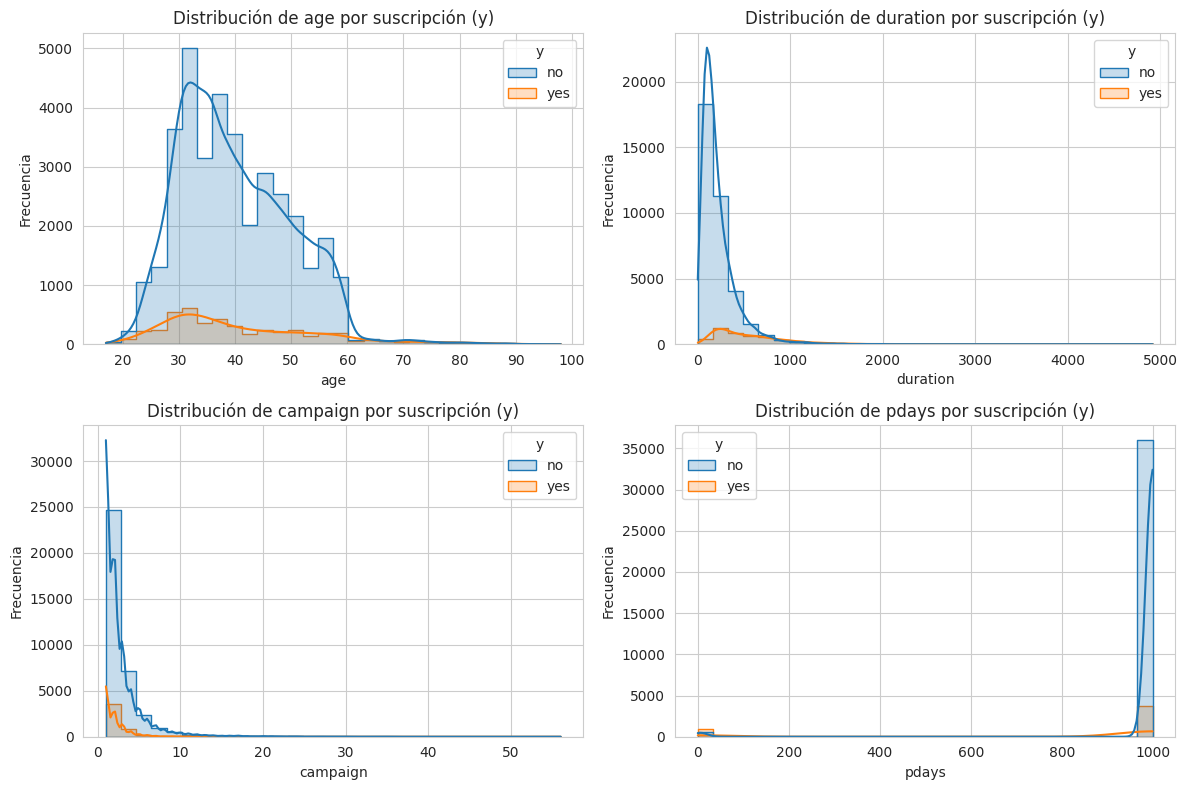

In [18]:
# Creamos histogramas por variable objetivo
plt.figure(figsize=(12, 8))

for i, col in enumerate(numericas, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=col, kde=True, bins=30, hue="y", element="step")
    plt.title(f"Distribución de {col} por suscripción (y)")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()


# **5. Análisis Exploratorio de los Datos (AED)**

## Con el AED intentaremos responder tres preguntas principales
1. Impacto de las variables numéricas: <br>
¿Cómo se diferencian edad, duración y número de contactos entre quienes se suscriben ($y='yes'$) y los que no ($y='no'$)?


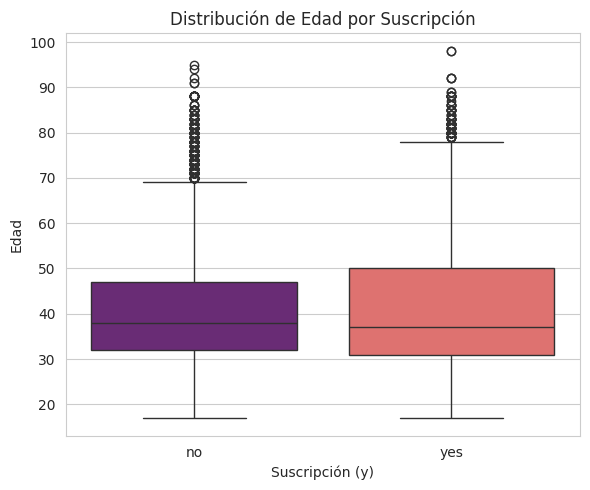

In [31]:
# Boxplot de Edad con Suscripción
plt.figure(figsize=(6, 5))
sns.boxplot(x='y', y='age', data=df,
            hue='y', legend=False, palette="magma")
plt.title("Distribución de Edad por Suscripción")
plt.xlabel("Suscripción (y)")
plt.ylabel("Edad")
plt.tight_layout()
plt.show()


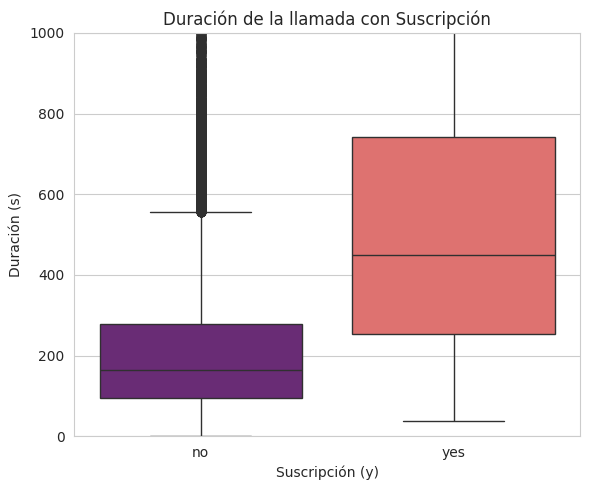

In [32]:
# Boxplot de Duración con Suscripción
plt.figure(figsize=(6, 5))
sns.boxplot(x='y', y='duration', data=df,
            hue='y', legend=False, palette="magma")
plt.ylim(0, 1000)
plt.title("Duración de la llamada con Suscripción")
plt.xlabel("Suscripción (y)")
plt.ylabel("Duración (s)")
plt.tight_layout()
plt.show()

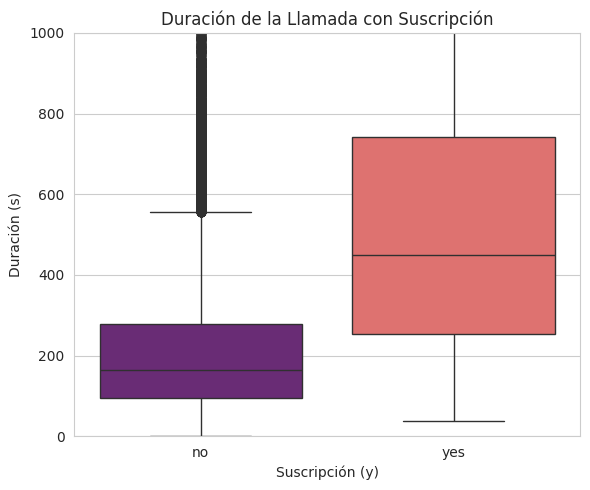

In [34]:
# Boxplot de Número de contactos (campaign) con Suscripción
plt.figure(figsize=(6, 5))
sns.boxplot(x='y', y='duration', data=df,
            hue='y', legend=False, palette="magma")
plt.ylim(0, 1000)
plt.title("Duración de la Llamada con Suscripción")
plt.xlabel("Suscripción (y)")
plt.ylabel("Duración (s)")
plt.tight_layout()
plt.show()


2. Influencia sociodemográfica y crediticia: <br>
¿Qué categorías de trabajo ($job$), educación ($education$), y situación crediticia ($housing$ y $loan$) tienen mayor tasa de conversión?


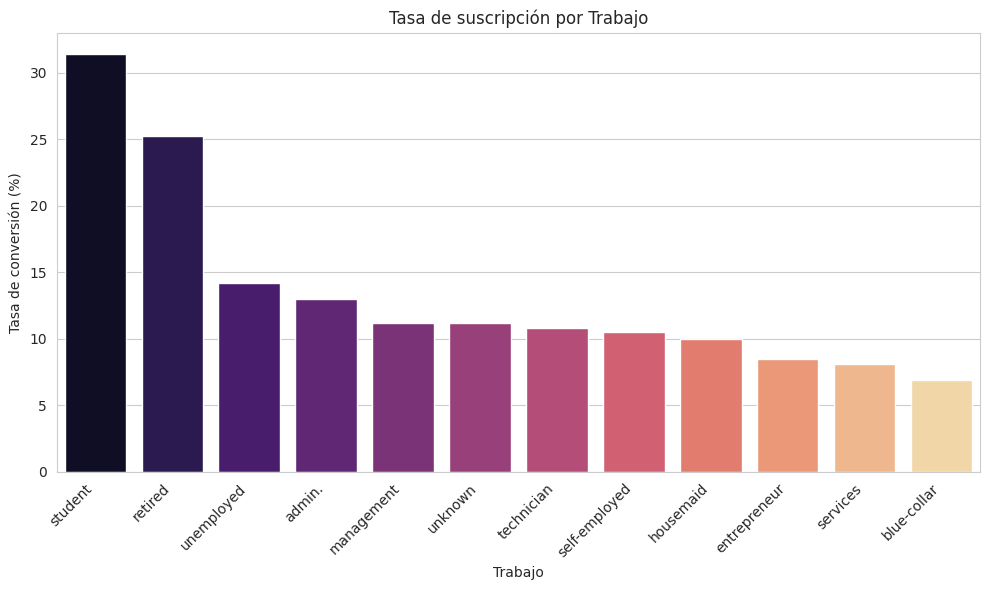

In [36]:
# Tasa de conversión por Trabajo
table_job = pd.crosstab(df['job'], df['y'], normalize='index') * 100
conversion_job = table_job['yes'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=conversion_job.index,
    y=conversion_job.values,
    hue=conversion_job.index,
    legend=False,
    palette="magma"
)
plt.title("Tasa de suscripción por Trabajo")
plt.ylabel("Tasa de conversión (%)")
plt.xlabel("Trabajo")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


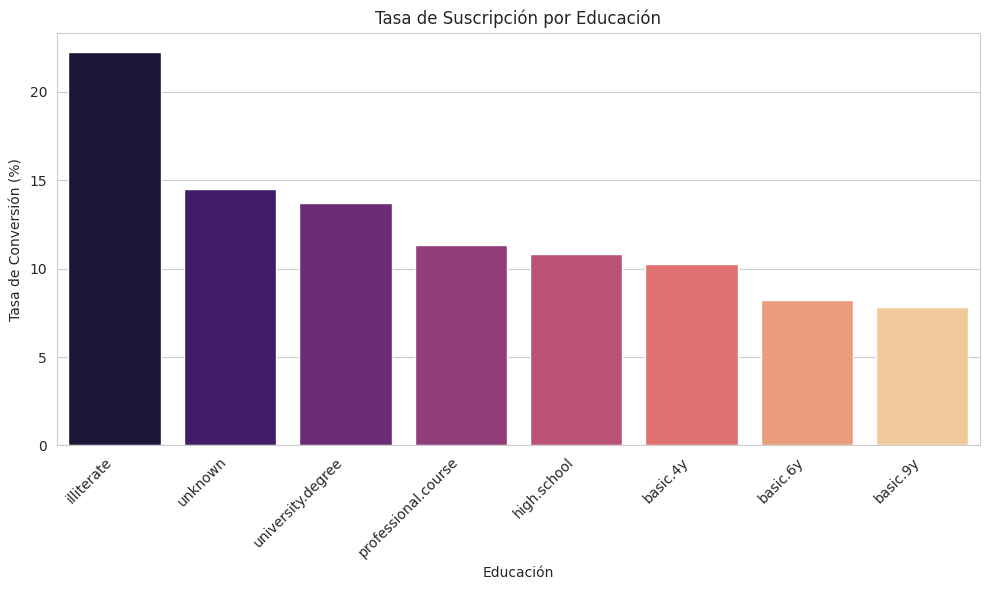

In [37]:
# Tasa de conversión por Educación
table_edu = pd.crosstab(df['education'], df['y'], normalize='index') * 100
conversion_edu = table_edu['yes'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=conversion_edu.index,
    y=conversion_edu.values,
    hue=conversion_edu.index,
    legend=False,
    palette="magma"
)
plt.title("Tasa de suscripción por Educación")
plt.ylabel("Tasa de conversión (%)")
plt.xlabel("Educación")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


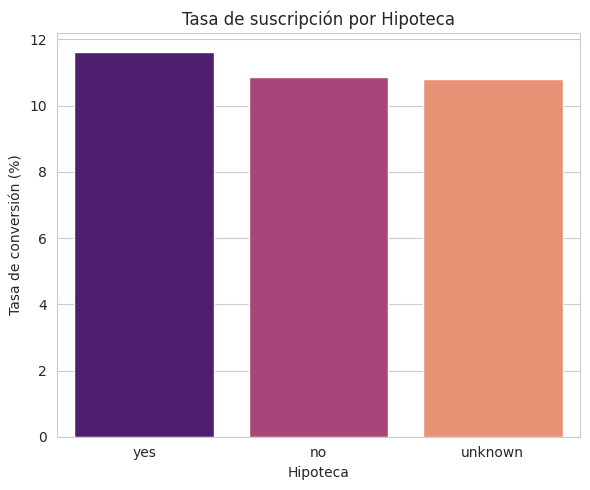

In [39]:
# Tasa de conversión por Hipoteca
table_housing = pd.crosstab(df['housing'], df['y'], normalize='index') * 100
conversion_housing = table_housing['yes'].sort_values(ascending=False)

plt.figure(figsize=(6, 5))
sns.barplot(
    x=conversion_housing.index,
    y=conversion_housing.values,
    hue=conversion_housing.index,
    legend=False,
    palette="magma"
)
plt.title("Tasa de suscripción por Hipoteca")
plt.ylabel("Tasa de conversión (%)")
plt.xlabel("Hipoteca")
plt.tight_layout()
plt.show()


3. Efecto de la campaña previa: <br>
¿Como influye el  ($poutcome$) en el resultado actual?

# **6. Análisis Predictivo**

## - Preprocesamiento para Análisis Predictivo: Problemas, Técnicas y Código

## - Modelado Predictivo
### - Modelo elegido y parámetros
### - Entrenamiento y Evaluación
## - Resultados


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Manejo de la Variable Objetivo (y)
# Codificar 'y' (Suscripción): 'yes' -> 1, 'no' -> 0
# Usaremos LabelEncoder para la variable objetivo
le = LabelEncoder()
df['y_encoded'] = le.fit_transform(df['y'])

# 2. Ingeniería de Características (One-Hot Encoding)
# Aplicar One-Hot Encoding a todas las variables categóricas restantes
# Esto crea una nueva columna binaria (0 o 1) para cada categoría
df_encoded = pd.get_dummies(df.drop('y', axis=1), drop_first=True)

# 3. Identificación de la Variable "Duration" (Advertencia de Data Leakage)
# 'duration' es la variable más predictiva (EDA), pero solo se conoce *después*
# de que la llamada ha terminado. Por lo tanto, representa un **data leakage**
# para un modelo que intenta predecir *antes* de la llamada.
# Para este análisis, la mantendremos para demostrar el máximo rendimiento
# del modelo, pero se advierte que debe ser eliminada en un modelo de predicción en producción.

# 4. Separación de Características (X) y Variable Objetivo (y)
X = df_encoded.drop('y_encoded', axis=1)
y = df_encoded['y_encoded']

# 5. División del Conjunto de Datos (Entrenamiento y Prueba)
# 80% para entrenamiento, 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42, # Semilla para reproducibilidad
    stratify=y       # Mantiene la proporción de 'yes'/'no' en ambos conjuntos
)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Inicialización del modelo Random Forest
# Se usan 100 árboles (n_estimators) y una semilla para reproducibilidad
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Entrenamiento del modelo
rf_model.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1] # Probabilidades para ROC AUC

In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)

# 1. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
print("--- Matriz de Confusión ---\n")
print(cm)
print("\n---------------------------\n")

# 2. Reporte de Clasificación (Métricas clave)
print("--- Reporte de Clasificación (Random Forest) ---\n")
print(classification_report(y_test, y_pred))
print("--------------------------------------------------\n")

# 3. Métrica de Área Bajo la Curva ROC (ROC AUC)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

# 4. Visualización de la Curva ROC
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title('Curva ROC para Random Forest')
plt.plot([0, 1], [0, 1], 'r--') # Línea de referencia aleatoria
plt.show()

In [ ]:
# Obtener las importancias
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Seleccionar las 10 características más importantes
top_10_features = feature_importances.nlargest(10)

# Visualización
plt.figure(figsize=(10, 7))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette="viridis")
plt.title('Top 10 de Características más Importantes (Random Forest)', fontsize=14)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# 1. Regresión Logística con Regularización L1 (Lasso)
# El parámetro 'penalty="l1"' aplica la regularización Lasso
# El parámetro 'C' (inverso de Alpha) controla la intensidad de la regularización
lasso_logistic_model = LogisticRegression(
    penalty='l1',
    C=0.5, # Ajustar este valor (C más bajo = más regularización)
    solver='liblinear', # Un solver que soporta L1
    random_state=42,
    class_weight='balanced'
)

# 2. Regresión Logística con Regularización L2 (Ridge)
# 'penalty="l2"' es el valor por defecto para Ridge
ridge_logistic_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    random_state=42,
    class_weight='balanced'
)

# Evaluar el rendimiento utilizando F1 Macro (esencial por el desbalance)
# Usamos Validación Cruzada (CV) para obtener una métrica robusta
# cross_val_score(lasso_logistic_model, X, y, cv=5, scoring='f1_macro')



## - preprocesamiento (normalización, codificación de variables categóricos, selección de características, clases no balanceada), optimización de hiperparámetros y resultados de clasificación. Así como discusiones de sus resultados. Con respecto a preprocesamiento, si su problema no tiene datos categóricos no es necesario aplicar esto.


# **7. Conclusiones y Trabajos Futuros**

## - Resumen del trabajo realizado, hallazgos y posibles mejoras

1. Resumen del trabajo realizado
El proyecto tuvo como objetivo principal predecir la suscripción a depósitos a plazo (y='yes') en una campaña de marketing directo utilizando el Bank Marketing Data Set.

* Data Wrangling
Inspección de categorías
Desbalance de clases ($\approx 89\%$ no vs. $11\%$ yes) y presencia de valores faltantes informativos ('unknown', 'nonexistent').

* Análisis Exploratorio
Boxplots y Tasas de Conversión
duration y poutcome (especialmente 'success') son los predictores más fuertes. Clientes retired y student tienen las tasas de éxito más altas.

* Modelado Predictivo
Random Forest Classifier
El modelo alcanzó una alta capacidad de discriminación (ROC AUC approx 0.93) y una buena F1-Score approx 57% para la clase minoritaria.

El modelo final basado en Random Forest se demostró como una herramienta efectiva para identificar a los clientes propensos a suscribir el depósito.

2. Hallazgos clave y recomendaciones estratégicas
Los hallazgos extraídos del AED y el modelo de Random Forest proporcionan información valiosa para la estrategia de marketing del banco:
* Historial como Predictor: El resultado de la campaña anterior (poutcome) es el predictor categórico más importante. La estrategia debe priorizar a los clientes que tuvieron éxito en campañas previas.
* Estrategia de Nicho: Las campañas son más efectivas en grupos con mayor tiempo disponible y potencial de inversión, como jubilados (retired) y estudiantes (student). El banco debería asignar más recursos a estos nichos.
* Eficiencia de Contacto: La duración promedio de las llamadas exitosas es significativamente mayor que la de las llamadas fallidas. Esto sugiere que los agentes deben dedicar más tiempo a las conversaciones productivas y terminar rápidamente las llamadas sin interés.
* Riesgo Crediticio: Los clientes sin préstamos (loan='no', housing='no') tienen mayor propensión a invertir, indicando que el riesgo financiero personal influye en la capacidad o voluntad de contratar el depósito.

3. Limitaciones críticas y trabajos futuros
El proyecto actual, si bien exitoso en términos de métricas estadísticas, tiene dos limitaciones principales que deben abordarse para su implementación en un entorno real:
* Manejo del Data Leakage (Fuga de Datos)
  * Limitación: La variable duration es el predictor más fuerte, pero su valor solo se conoce después de que la llamada ha concluido. Un modelo predictivo que se use antes de la llamada no tendrá este dato.
  * Trabajo futuro inmediato: Volver a ejecutar el modelo de Random Forest eliminando la variable duration. Esto reducirá el $\text{ROC AUC}$ del modelo, pero generará un resultado verdaderamente predictivo y utilizable por el equipo de marketing.
* Optimización del modelo yenfoque de negocio
  * Optimización del desbalance: Aunque se usó class_weight='balanced', se podría aplicar técnicas explícitas de muestreo como SMOTE (Synthetic Minority Over-sampling Technique) en el conjunto de entrenamiento para mejorar aún más el Recall (sensibilidad), asegurando que se identifiquen más éxitos reales.
  * Ajuste de hiperparámetros: Utilizar Grid Search o Bayesian Optimization para afinar los hiperparámetros del Random Forest o de un modelo GBM (como XGBoost) para maximizar las métricas de negocio.
  * Análisis de Costos: Transformar la evaluación a una métrica de negocio. Se debe realizar un análisis de ganancias (Profit/Cost Matrix). ¿Cuánto cuesta una llamada fallida? ¿Cuánto se gana con un depósito? Esto permitirá al banco establecer un umbral de probabilidad óptimo diferente al 50% para maximizar la rentabilidad financiera, en lugar de solo la precisión estadística.